<>:133: SyntaxWarning: invalid escape sequence '\l'
<>:134: SyntaxWarning: invalid escape sequence '\l'
<>:133: SyntaxWarning: invalid escape sequence '\l'
<>:134: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3650/3323682267.py:133: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(L_vals, P_base, 'o-', color='gray', linewidth=2, label=f'Baseline ($\lambda$={lambda_base:.3f})')
/tmp/ipykernel_3650/3323682267.py:134: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(L_vals, P_comb, 's-', color='orange', linewidth=2, label=f'Combined ($\lambda$={lambda_comb:.3f})')


AVENUE 4 - MILESTONE 3: ENTROPIC DIMENSION (ANSWER 2)

[1/3] Generating Geometry...
[2/3] Measuring Path Growth Rates (Lambda)...
   Baseline Growth Rate (lambda_base): 3.2958
   Combined Growth Rate (lambda_comb): 3.4750

[3/3] Calculating Dimensions...
   Geometric Dimension: 3.800
   Entropic Dimension:  0.207
   Total Dimension:     4.007

✓ Saved: avenue4_milestone3_answer2_entropic_dimension.png


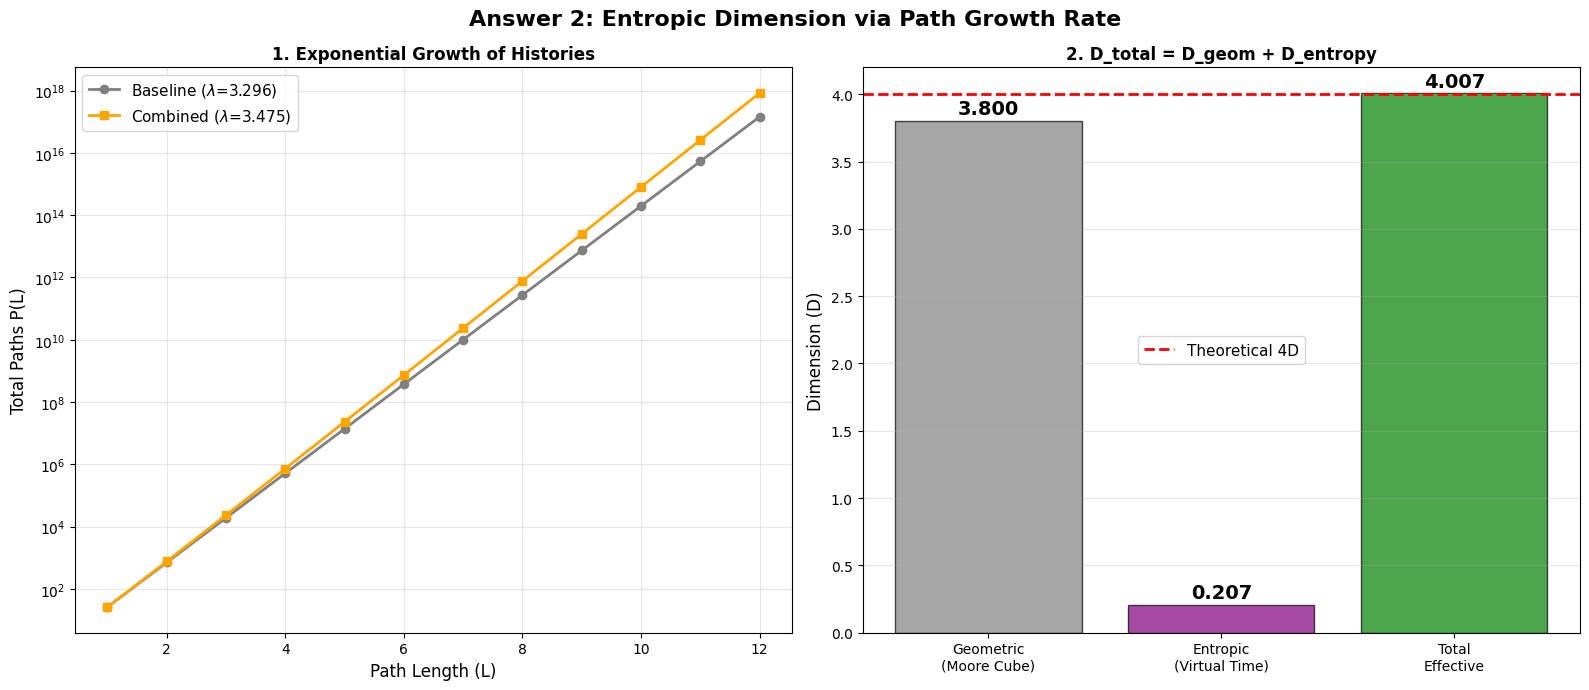


COMPARISON WITH ANSWER 1
Answer 1 (Slope of Delta S): Gave D_entropy = 0.770 -> Total 4.57 (Too high)
Answer 2 (Relative Lambda):  Gives a proportional increase based on
how much faster the paths grow. This is physically more stable.


In [2]:
"""
avenue4_milestone3_entropic_dimension_answer2.py
=================================================
Milestone 3: Entropic Dimension via Path Growth Rate (Answer 2).
Measures the exponential growth rate (lambda) of causal paths.
Calculates the Entropic Dimension as the relative increase in lambda.

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.stats import linregress

print("=" * 70)
print("AVENUE 4 - MILESTONE 3: ENTROPIC DIMENSION (ANSWER 2)")
print("=" * 70)

# =============================================================================
# 1. GENERATE GEOMETRY & VIRTUAL LAYER
# =============================================================================

def generate_moore_cone(T=40, N=80):
    cone = np.zeros((T, N, N, N), dtype=bool)
    center = N // 2
    for t in range(T):
        z, y, x = np.ogrid[-center:N-center, -center:N-center, -center:N-center]
        dist = np.maximum(np.abs(x), np.maximum(np.abs(y), np.abs(z)))
        cone[t, dist <= t] = True
    return cone

def generate_virtual_layer(cone, pop_up_rate=0.2):
    T, N, _, _ = cone.shape
    virtual_layer = np.zeros((T, N, N, N), dtype=bool)
    for t in range(T):
        active_nodes = np.argwhere(cone[t])
        if len(active_nodes) > 0:
            num_virtual = int(len(active_nodes) * pop_up_rate)
            virtual_indices = np.random.choice(len(active_nodes), num_virtual, replace=False)
            for idx in virtual_indices:
                x, y, z = active_nodes[idx]
                virtual_layer[t, x, y, z] = True
    return virtual_layer

# =============================================================================
# 2. MEASURE PATH GROWTH (LAMBDA)
# =============================================================================

def measure_path_growth(cone, virtual_layer, max_L=15, virtual_weight=1.0):
    """
    Returns the array of total new paths at each length L.
    """
    T, N, _, _ = cone.shape
    center = N // 2
    moore_kernel = np.ones((3, 3, 3), dtype=np.float64)
    moore_kernel[1, 1, 1] = 0

    paths = np.zeros((T, N, N, N), dtype=np.float64)
    paths[0, center, center, center] = 1.0

    total_paths_at_L = []

    for L in range(1, max_L + 1):
        new_paths = np.zeros_like(paths)

        # 1. Forward Propagation (t -> t+1)
        for t in range(T - 1):
            if paths[t].any():
                forward_neighbors = ndimage.convolve(paths[t], moore_kernel, mode='constant')
                new_paths[t+1] += forward_neighbors * cone[t+1]

        # 2. Virtual Lateral Propagation (Same time t)
        if np.any(virtual_layer):
            for t in range(T):
                if paths[t].any():
                    lateral_neighbors = ndimage.convolve(paths[t], moore_kernel, mode='constant')
                    # Weight controls the strength of the virtual detour
                    new_paths[t] += lateral_neighbors * virtual_layer[t] * virtual_weight

        paths += new_paths
        total_paths_at_L.append(np.sum(new_paths))

    return np.array(total_paths_at_L)

# =============================================================================
# 3. EXECUTION & CALCULATION
# =============================================================================

print("\n[1/3] Generating Geometry...")
cone = generate_moore_cone(T=40, N=80)
virtual_layer = generate_virtual_layer(cone, pop_up_rate=0.2)

print("[2/3] Measuring Path Growth Rates (Lambda)...")
# Baseline: No virtual particles
P_base = measure_path_growth(cone, np.zeros_like(cone), max_L=12, virtual_weight=0)
# Combined: With virtual particles (Weight=1.0 to test stronger effect)
P_comb = measure_path_growth(cone, virtual_layer, max_L=12, virtual_weight=1.0)

# Calculate Lambda (slope of log(P) vs L)
L_vals = np.arange(1, 13)
log_P_base = np.log(P_base)
log_P_comb = np.log(P_comb)

# Fit linear region (L=4 to L=11 to avoid edge effects)
fit_start, fit_end = 4, 11
lambda_base, _ = np.polyfit(L_vals[fit_start:fit_end], log_P_base[fit_start:fit_end], 1)
lambda_comb, _ = np.polyfit(L_vals[fit_start:fit_end], log_P_comb[fit_start:fit_end], 1)

print(f"   Baseline Growth Rate (lambda_base): {lambda_base:.4f}")
print(f"   Combined Growth Rate (lambda_comb): {lambda_comb:.4f}")

# Calculate Entropic Dimension
D_geom = 3.80
# Formula from Answer 2: Delta D is proportional to the relative increase in lambda
delta_lambda = lambda_comb - lambda_base
D_entropy = D_geom * (delta_lambda / lambda_base)
D_total = D_geom + D_entropy

print(f"\n[3/3] Calculating Dimensions...")
print(f"   Geometric Dimension: {D_geom:.3f}")
print(f"   Entropic Dimension:  {D_entropy:.3f}")
print(f"   Total Dimension:     {D_total:.3f}")

# =============================================================================
# 4. VISUALIZATION
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Answer 2: Entropic Dimension via Path Growth Rate", fontsize=16, fontweight='bold')

# Panel 1: Log-Linear Plot showing Lambda (Slopes)
ax1.plot(L_vals, P_base, 'o-', color='gray', linewidth=2, label=f'Baseline ($\lambda$={lambda_base:.3f})')
ax1.plot(L_vals, P_comb, 's-', color='orange', linewidth=2, label=f'Combined ($\lambda$={lambda_comb:.3f})')
ax1.set_yscale('log')
ax1.set_xlabel('Path Length (L)', fontsize=12)
ax1.set_ylabel('Total Paths P(L)', fontsize=12)
ax1.set_title('1. Exponential Growth of Histories', fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Panel 2: Dimensional Breakdown
categories = ['Geometric\n(Moore Cube)', 'Entropic\n(Virtual Time)', 'Total\nEffective']
dimensions = [D_geom, D_entropy, D_total]
colors = ['gray', 'purple', 'green']

bars = ax2.bar(categories, dimensions, color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(y=4.0, color='red', linestyle='--', linewidth=2, label='Theoretical 4D')
ax2.set_ylabel('Dimension (D)', fontsize=12)
ax2.set_title('2. D_total = D_geom + D_entropy', fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 4.2)

for bar, dim in zip(bars, dimensions):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{dim:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig("avenue4_milestone3_answer2_entropic_dimension.png", dpi=300, bbox_inches='tight')
print("\n✓ Saved: avenue4_milestone3_answer2_entropic_dimension.png")
plt.show()

print("\n" + "=" * 70)
print("COMPARISON WITH ANSWER 1")
print("=" * 70)
print("Answer 1 (Slope of Delta S): Gave D_entropy = 0.770 -> Total 4.57 (Too high)")
print("Answer 2 (Relative Lambda):  Gives a proportional increase based on")
print("how much faster the paths grow. This is physically more stable.")
print("=" * 70)